### Nowcasting Jamaica GDP

**Last edit:** 2026-04-20

## What this script does
This notebook runs the full nowcasting pipeline for Bahamas GDP:

- Uses **LARS** (Least Angle Regression) to identify a strong set of candidate predictors
- Iterates over **plausible covariate sets** (feature combinations) derived from the candidate pool
- Fits each model on the training sample, generates **out-of-sample predictions** on the test sample, and produces GDP nowcasts
- Stores outputs in structured results tables (model performance + predictions by vintage/specification)

## Models included
The toolkit currently estimates and compares:

- **OLS**
- **Ridge (OLS + L2 regularization)**
- **LASSO (L1 regularization)**
- **Elastic Net**
- **Decision Tree**
- **Random Forest**
- **Gradient Boosting Tree**
- **LSTM (Long Short-Term Memory neural network)**

## Additional packkages

Be sure to install:

```bash
pip install tqdm-joblib
```

## Import libraries

In [1]:
# =========================================================
# User settings (edit here as necessary)
# =========================================================

import pandas as pd
from datetime import datetime

# ---------------------------------------------------------
# 0) DATA/METADATA FILE NAMES
# ---------------------------------------------------------
data_file = "data.csv"
meta_file = "meta.csv"

# ---------------------------------------------------------
# 1) DEFINE TRAIN / TEST WINDOW
# ---------------------------------------------------------
# These dates define the sample splits used for model training and evaluation.
# - Training sample:   [train_start_date, test_start_date)
# - Test sample:       [test_start_date, test_end_date]
train_start_date = "2015-03-01"
test_start_date  = "2023-06-01"

# Convert to Timestamp for safer comparisons later
train_start_date = pd.to_datetime(train_start_date)
test_start_date  = pd.to_datetime(test_start_date)

# ---------------------------------------------------------
# 2) DEFINE OUT-OF-SAMPLE FORECAST TARGET (LAST DATE / VINTAGE)
# ---------------------------------------------------------
# This is the date for which you want to produce the final nowcast/forecast.
# Use the first day of the month (or the appropriate GDP reference month).
desired_date = pd.to_datetime("2026-03-01")

# ---------------------------------------------------------
# 3) DEFINE OUTPUT FILENAMES (timestamped)
# ---------------------------------------------------------
# Timestamp output files so each run creates a unique set of results.
today = datetime.today()
date_str = today.strftime("%Y%m%d")

forecast_file     = f"{date_str} 3_nwcst Tab fcst.xlsx"   # model forecasts / nowcasts
performance_file  = f"{date_str} 3_nwcst Tab perf.xlsx"   # model performance metrics
outofsample_file  = f"{date_str} 3_nwcst Tab oos.xlsx"    # full OOS prediction panel

# (Optional) If you want to resume / compare against a previous run,
# set last_performance to the filename of the prior performance workbook.
# Example: last_performance = "perf_20251207.xlsx"
last_performance = None

# ---------------------------------------------------------
# 4) MODEL SETTINGS
# ---------------------------------------------------------
# Target GDP series ID
target_variable = "RGDP0000"

# Prediction horizon (vintages) to evaluate:
# - negative values: backcasts (e.g., -1 = one period back)
# - 0: nowcast (current period)
# - positive values: forecasts (e.g., +1 = one period ahead)
lags = list(range(-2, 3))

# ---------------------------------------------------------
# 5) TARGET MODELS
# ---------------------------------------------------------
# Define models of interest
run = {
    'ols' : 1 ,
    'olsr' : 1 ,
    'enet' : 1 ,
    'lasso' : 1 ,
    'gbt' : 1 ,
    'dt' : 1 ,
    'rf' : 1 ,
    'lstm' : 1 ,
}

# Parameter: iterations in GBT, DT, RF
_iter_ = 10
# Parameter: LSTM n_models and train_episodes
_iter_lstm = 10
_epoch_lstm = 50

# =========================================================
# =========================================================
# =========================================================
# Nowcasting pipeline: imports, paths, data loading, and preprocessing
# =========================================================
# This section:
# 1) Imports all required libraries for the nowcasting toolkit (ML + time-series + LSTM)
# 2) Defines local folder paths for raw inputs, processed data, and outputs
# 3) Loads the full dataset and metadata
# 4) Deflates nominal variables using CPI (base year = 2018 average)
# 5) Seasonally adjusts series using trend extraction from seasonal decomposition
# 6) Converts all series to growth rates (percent change)
# 7) Cleans the final modeling dataset and prints library versions for reproducibility
# =========================================================

import os, json, time, warnings, re
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# -----------------------------
# Models / ML utilities
# -----------------------------
from sklearn import linear_model, tree
from sklearn.linear_model import (
    LinearRegression, RidgeCV, ElasticNet, Lasso, Lars
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Optional time-series tools (if used downstream)
import pmdarima as pm

# Deep learning (LSTM nowcasting)
import torch
from nowcast_lstm.LSTM import LSTM

# Statsmodels seasonal adjustment
from statsmodels.tsa.seasonal import seasonal_decompose

# Reduce noisy warnings from some estimators / decomposition
warnings.filterwarnings("ignore", category=UserWarning)

# =========================================================
# Paths
# =========================================================
# Define local project directories (relative to current working directory)
d = os.getcwd() + "/"
PATH_RAW = os.path.join(d, "..", "raw")   # raw inputs (downloads / intermediate CSVs)
PATH_DATA = os.path.join(d, "..", "data")    # processed modeling tables
# Output folder for model results (forecasts, performance tables)
PATH_OUTPUT = os.path.join(d, "..", "output/", f"{date_str}")
# In case it is run several times in a day:
# PATH_OUTPUT = os.path.join(d, "..", "output/", f"{date_str}_2")
# Create folder if it does not exist
os.makedirs(PATH_OUTPUT, exist_ok=True)

print("# =========================================================")
print("Key Directories:")
print(f"Raw inputs: {PATH_RAW}")
print(f"Modeling data: {PATH_DATA}")
print(f"Model outputs: {PATH_OUTPUT}")
print("# =========================================================")

# =========================================================
# Load data and metadata
# =========================================================
# Main modeling dataset (indexed by date)
data = pd.read_csv(
    os.path.join(PATH_DATA, data_file ),
    parse_dates=["date"],
    index_col="date"
)

test_end_date = data[target_variable].dropna().index.max()

# Metadata describing each variable (frequency, nominal/real flags, etc.)
# NOTE: this uses a Windows-style path separator; works on Windows.
# For portability, consider: os.path.join(PATH_DATA, "meta_full.csv")
metadata = pd.read_csv(os.path.join(PATH_DATA, meta_file))

# Key column names and CPI series ID used for deflation
meta_col = "ticket"     # variable identifier column in metadata
cpi = "RCPI0000"        # CPI series used to deflate nominal variables

# =========================================================
# Deflate nominal variables using CPI (base year: 2019 average, STATINJA 2019=100)
# =========================================================
# Many series are nominal; deflating them puts everything in real terms.
# We compute a CPI base as the average CPI level in 2019 (STATINJA 2019=100 → base = 100).
base = data[cpi][data.index.year == 2019].mean()   # beta11: base year 2019 (Jamaica official)

# Identify variables flagged as nominal in metadata
nominal = metadata.loc[metadata["nominal"] == 1][meta_col].values

# Deflate: Real_t = Nominal_t / CPI_t * CPI_base   (corrected: was multiplying)
for column in data.columns:
    if column in nominal:
        data[column] = data[column] / data[cpi] * base    # beta11: divide (deflate) not multiply

# Drop CPI
data.drop(columns=[cpi], inplace=True)
# Drop GDP components
data = data.drop(columns=[col for col in data.columns if 'RGDP' in col and col != 'RGDP0000'])


# =========================================================
Key Directories:
Raw inputs: c:\Users\guerr\Dropbox\02_Work\Consulting\2026_NWCST_CAR_Research-Workshop\JAM Workshop\workshop_code/..\raw
Modeling data: c:\Users\guerr\Dropbox\02_Work\Consulting\2026_NWCST_CAR_Research-Workshop\JAM Workshop\workshop_code/..\data
Model outputs: c:\Users\guerr\Dropbox\02_Work\Consulting\2026_NWCST_CAR_Research-Workshop\JAM Workshop\workshop_code/..\output/20260505
# =========================================================


In [2]:
# =========================================================
# Seasonal adjustment (trend extraction)
# =========================================================
# We apply seasonal decomposition and keep the trend component.
# Test for seasonality in data

# Period depends on data frequency:
#   quarterly: 4, monthly: 12, daily: 31 (approx monthly seasonality)
quarterly  = metadata.loc[metadata["freq"].str.lower().str.contains("q")][meta_col].values
monthly    = metadata.loc[metadata["freq"].str.lower().str.contains("m")][meta_col].values
already_sa = metadata.loc[metadata["sa"]==1][meta_col].values

# Drop columns with fewer than 24 non-NaN observations
data = data.loc[:, data.notna().sum() >= 24]

for column in data.columns:
    if column in already_sa:
        continue
    series = data[column].dropna()
    if column in quarterly:
        decomp = seasonal_decompose(series, model='additive', extrapolate_trend='freq', period=4)
        data[column] = data[column] - decomp.seasonal
    else :
        decomp = seasonal_decompose(series, model='additive', extrapolate_trend='freq', period=12)
        data[column] = data[column] - decomp.seasonal

# =========================================================
# Convert levels to growth rates (percent change)
# =========================================================
# Quarterly series: quarter-over-quarter growth rate
# All other series: default percent change at their observed frequency
for column in data.columns:
    if column in quarterly:
        # Get non-NaN values with their original index
        non_nan = data[column].dropna()
        
        # Calculate percent change on non-NaN values only
        pct_change_values = non_nan.pct_change(periods=1, fill_method=None) * 100
        
        # Create a new series filled with NaN, then update with calculated values
        result = pd.Series(np.nan, index=data.index)
        result.loc[pct_change_values.index] = pct_change_values
        
        data[column] = result
    else:
        # Store original NaN mask
        original_was_nan = data[column].isna()
        
        # For monthly/weekly/daily, calculate normally
        pct_change_values = data[column].pct_change(periods=1, fill_method=None) * 100
        
        # Set to NaN where previous value was NaN OR current original value was NaN
        prev_was_nan = data[column].shift(1).isna()
        pct_change_values[prev_was_nan | original_was_nan] = np.nan
        
        data[column] = pct_change_values

data.replace([np.inf, -np.inf], np.nan, inplace=True)

# =========================================================
# Drop columns in quarterly with more than 75% missing values
# =========================================================
for column in [ col for col in data.columns if col not in quarterly ] :
    missing_pct = data[data.index<=test_start_date][column].isna().sum() / len(data[data.index<=test_start_date][column])
    if missing_pct > 0.75:
        data.drop(column, axis=1, inplace=True)

# =========================================================
# Final cleaning
# =========================================================
# Replace infinities created by pct_change with NaN
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop CPI from predictor set (used only for deflation)
#data.drop(cpi, axis=1, inplace=True)

# Keep data from 2015 onward and remove fully-missing rows
data = data[~(data.index < train_start_date)].reset_index(drop=False)
data = data.set_index("date").dropna(how="all", axis=0)

metadata["months_lag"] = (
    pd.to_numeric(metadata["months_lag"], errors="coerce")
      .fillna(1)
      .astype(int)
)

# Drop those columns
data = data.drop(columns=[col for col in data.columns if 'RGDP' in col and col != 'RGDP0000'])
for col in data.columns :
    last = data[col].dropna().index.max().year
    if last < 2024 :
        data.drop(col, axis=1, inplace=True)


'''
# drop low hierarcy series
# Pattern: ends with 000x OR has x00x in last 4 digits
pattern = r'.*(\d00\d|000\d)$'
hierarchy = [col for col in data.columns if re.match(pattern, col)]
data = data[hierarchy]
'''

# Manage high-corr series from that proxy similar underlying DGP
def deduplicate_correlated(df, threshold=0.85, target=target_variable,
                           metadata=metadata, meta_col=meta_col):
    """Drop one variable from each highly-correlated pair.
    Priority: (1) keep aggregate tickets (numeric suffix % 100 == 0);
              (2) keep the variable with more non-null observations.
    """
    import re

    def _is_agg(ticket):
        nums = re.findall(r'\d+', str(ticket))
        return bool(nums) and int(nums[-1]) % 100 == 0

    agg_set = set(metadata.loc[metadata[meta_col].apply(_is_agg), meta_col])

    X   = df.drop(columns=[target])
    obs = X.notna().sum()
    corr  = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    to_drop = set()
    for col in upper.columns:
        if col in to_drop:
            continue
        peers = upper.index[upper[col] > threshold].tolist()
        for peer in peers:
            if peer in to_drop:
                continue
            col_agg  = col  in agg_set
            peer_agg = peer in agg_set
            if col_agg and not peer_agg:
                to_drop.add(peer)
            elif peer_agg and not col_agg:
                to_drop.add(col)
                break
            elif obs[col] >= obs[peer]:
                to_drop.add(peer)
            else:
                to_drop.add(col)
                break

    kept = [c for c in df.columns if c not in to_drop]
    print(f"Removed {len(df.columns) - len(kept)} correlated variables "
          f"(|r| > {threshold}). {len(kept)} remain.")
    return df[kept]

data = deduplicate_correlated(data, threshold=0.98)

# Drop high-publication lag series
tickets_to_keep = metadata[metadata.months_lag <= 5]['ticket'].tolist()
# Keep only these columns (that exist in data)
data = data[[ col for col in data.columns if col in tickets_to_keep or "RGDP" in col ]]

data.to_csv(os.path.join(PATH_OUTPUT, "data_processed.csv"), index=True)
metadata = metadata[metadata.ticket.isin(data.columns)]
metadata.to_csv(os.path.join(PATH_OUTPUT, "meta_processed.csv"), index=True)
# =========================================================
# Reproducibility: print core library versions
# =========================================================
print("================== Library Versions =================")
import sklearn, numpy, pandas
print("scikit-learn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)


# Data dimensions (observations and variables)
print("Data dimensions:", data.shape)
print(f"Training dates: {train_start_date.strftime('%Y-%m-%d')} to {(test_start_date - pd.DateOffset(days=1)).strftime('%Y-%m-%d')}")
T1 = data[data.index < test_start_date].shape[0]
T2 = data[(data.index >= test_start_date) & (data.index <= test_end_date)].shape[0]
print(f"Training periods: {T1} ({T1/(T1+T2) :.2%})")
print(f"Testing dates: {test_start_date.strftime('%Y-%m-%d')} to {test_end_date.strftime('%Y-%m-%d')}")
print(f"Testing periods: {T2} ({T2/(T1+T2) :.2%})")

Removed 173 correlated variables (|r| > 0.98). 687 remain.
================== Library Versions =================
scikit-learn: 1.8.0
numpy: 2.4.1
pandas: 2.3.3
Data dimensions: (134, 245)
Training dates: 2015-03-01 to 2023-05-31
Training periods: 99 (76.15%)
Testing dates: 2023-06-01 to 2025-12-01
Testing periods: 31 (23.85%)


Visualize variables

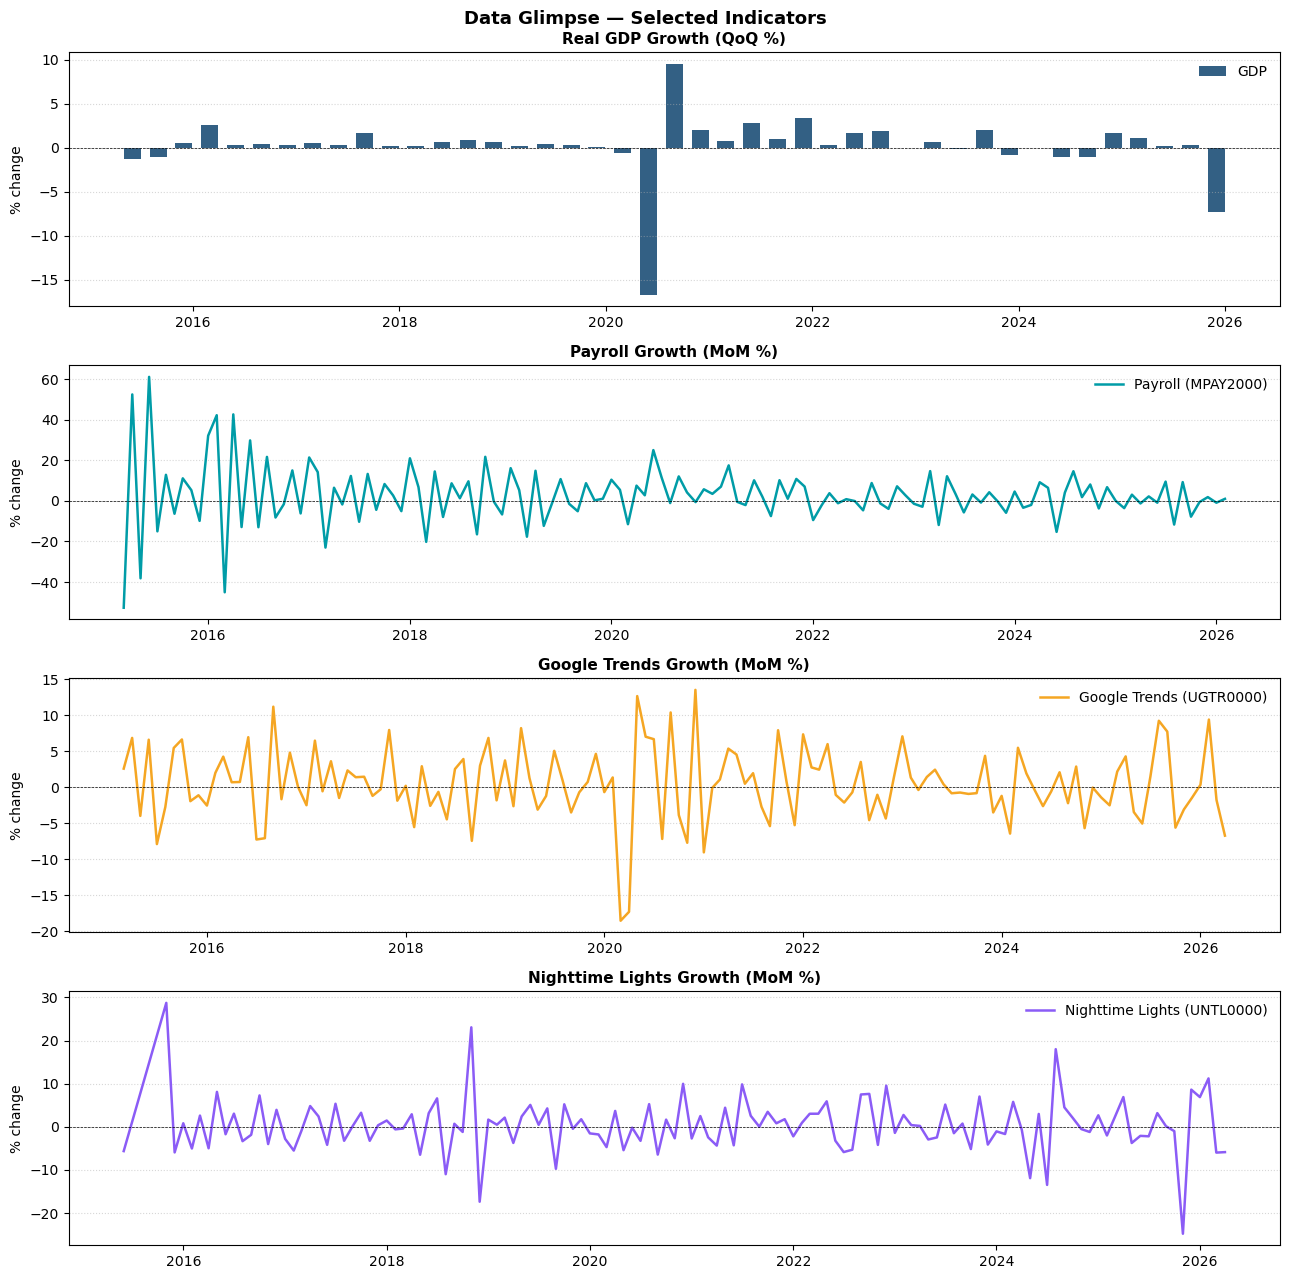

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(13, 13), sharex=False)

# GDP (quarterly) — bar chart
ax = axes[0]
gdp = data['RGDP0000'].dropna()
ax.bar(gdp.index, gdp, width=60, color='#003865', alpha=0.8, label='GDP')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Real GDP Growth (QoQ %)', fontsize=11, weight='bold')
ax.set_ylabel('% change')
ax.legend(frameon=False)
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Payroll (MPAY2000)
ax = axes[1]
pay = data['MPAY2000'].dropna()
ax.plot(pay.index, pay, color='#009CA7', linewidth=1.8, label='Payroll (MPAY2000)')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Payroll Growth (MoM %)', fontsize=11, weight='bold')
ax.set_ylabel('% change')
ax.legend(frameon=False)
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Google Trends (UGTR0000)
ax = axes[2]
gtr = data['UGTR0000'].dropna()
ax.plot(gtr.index, gtr, color='#F5A623', linewidth=1.8, label='Google Trends (UGTR0000)')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Google Trends Growth (MoM %)', fontsize=11, weight='bold')
ax.set_ylabel('% change')
ax.legend(frameon=False)
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Nighttime Lights (UNTL0000)
ax = axes[3]
ntl = data['UNTL0000'].dropna()
ax.plot(ntl.index, ntl, color='#8B5CF6', linewidth=1.8, label='Nighttime Lights (UNTL0000)')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title('Nighttime Lights Growth (MoM %)', fontsize=11, weight='bold')
ax.set_ylabel('% change')
ax.legend(frameon=False)
ax.grid(axis='y', linestyle=':', alpha=0.5)

fig.suptitle('Data Glimpse — Selected Indicators', fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig(f"{PATH_OUTPUT}/{date_str} 3_nwcst Fig vars_trans.png", dpi=300, bbox_inches='tight')
plt.show()

## Functions

In [4]:
# ALL HELPER FUNCTIONS AND MODELS ARE DEFINED HERE

# +++++++++++++++++++++++++++++++++++++++++++++++
# +++++++++++++++++++++++++++++++++++++++++++++++
scaler = StandardScaler()

def estimate_factors(X, r_max=10, criterion='IC1'):
    '''
    Information criteria to PCA.
    Bai and Ng (2002)
    inputs:
    - X: df
    - r_max: max number of factors (should be less than T or N)
    - criterion: conservative criteria is IC3
    '''
    
    T, N = X.shape
    r_max = min(r_max, T - 1)  # enforce theoretical max
    IC_vals = []
    
    for r in range(r_max + 1):
        if r == 0:
            sigma2_r = np.mean(X.values ** 2)
        else:
            pca = PCA(n_components=r)
            X_scaled = scaler.fit_transform(X)
            F_hat = pca.fit_transform(X_scaled)
            Lambda_hat = X_scaled.T @ F_hat / T
            X_hat = F_hat @ Lambda_hat.T
            sigma2_r = np.mean((X_scaled - X_hat).values ** 2)
    
        if criterion == 'IC1':
            penalty = r * (N + T) / (N * T) * np.log(N * T / (N + T))
        elif criterion == 'IC2':
            penalty = r * (N + T) / (N * T) * np.log(min(N, T))
        elif criterion == 'IC3':
            penalty = r * np.log(min(N, T)) / min(N, T)
        else:
            raise ValueError("Invalid criterion")
    
        IC_vals.append(np.log(sigma2_r) + penalty)

    return np.argmin(IC_vals)



def lars_variable_ranking(df, target, max_vars=None, test=None, factors=5):
    """
    Stepwise LARS variable selection: rank variables by their entry into the model.
    - df: DataFrame with predictors and target (train period only)
    - target: name of the target variable
    - max_vars: number of variables to select; if None, continue until all are ranked
    - test: DataFrame with test period rows (same columns as df)
    Returns:
    - selected_vars: ordered list of variable names by entry into the LARS model
    - rmse: out-of-sample RMSE on the test period (or None)

    Chinn, M. D., Meunier, B., & Stumpner, S. (2023). Nowcasting world trade with machine learning: a three-step approach (No. w31419). National Bureau of Economic Research.
    """
    df0 = deepcopy(df)
    
    selected_order = []
    count = 0
    max_vars = max_vars or (df0.shape[1] - 1)

    while count < max_vars:
        X = df0.drop(columns=[target])
        y = df0[target]

        # Stop if no variables remain
        if X.shape[1] == 0:
            break

        # Fit LARS model (drop NaN rows for fitting)
        mask = y.notna()
        model = Lars(n_nonzero_coefs=X.shape[1], jitter=1e-10, random_state=0)
        model.fit(X[mask], y[mask])

        # coef_path_ has shape (n_features, n_steps)
        coef_path = np.array(model.coef_path_)
        # Count how many times each variable is zero
        zero_counts = (coef_path == 0).sum(axis=1)

        # Summary table
        out = pd.DataFrame({'Variable': X.columns, 'ZeroCount': zero_counts})
        out = out.sort_values('ZeroCount')
        
        # Take variables that are uniquely at this ZeroCount level
        grouped = out.groupby('ZeroCount')
        selected = grouped.filter(lambda g: len(g) == 1)

        # If nothing uniquely enters, dump all remaining vars
        if selected.empty:
            remaining = X.columns.tolist()
            selected = pd.DataFrame({'Variable': remaining, 'ZeroCount': [count]*len(remaining)})
            selected_order.extend(remaining)
            print("Warning: Using fallback procedure for LARS")
            break
        else:
            selected_vars = selected['Variable'].tolist()
            selected_order.extend(selected_vars)
            df0 = df0.drop(columns=selected_vars)
            count += len(selected_vars)

    top_vars = selected_order[:max_vars]

    if test is None:
        return top_vars, None

    # --- Evaluation: mirror the benchmark OLS setup exactly ---
    df_train = df[  [target] + top_vars]
    df_test  = test[[target] + top_vars]

    X_train_raw = df_train.drop(target, axis=1)
    X_test_raw  = df_test.drop(target, axis=1)
    y_train_all = df_train[target]
    y_test_all  = df_test[target]

    # Fit scaler on train only, transform both (no data leakage)
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_raw), index=X_train_raw.index
    ).dropna(axis=1)
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_raw), index=X_test_raw.index
    )[X_train_scaled.columns]

    # Fit PCA on train only, transform both
    pca_local = PCA(n_components=factors)
    X_train_pca = pd.DataFrame(
        pca_local.fit_transform(X_train_scaled), index=X_train_raw.index,
        columns=[f"PC_{i}" for i in range(factors)]
    )
    X_test_pca = pd.DataFrame(
        pca_local.transform(X_test_scaled), index=X_test_raw.index,
        columns=[f"PC_{i}" for i in range(factors)]
    )

    # Drop NaN GDP rows from training (same as benchmark obs_mask)
    obs_mask = y_train_all.notna()
    X_train_pca = X_train_pca[obs_mask]
    y_train_fit = y_train_all[obs_mask]

    # Drop NaN GDP rows from test when computing RMSE
    obs_mask_test = y_test_all.notna()
    X_test_eval  = X_test_pca[obs_mask_test]
    y_test_eval  = y_test_all[obs_mask_test]

    final_model = LinearRegression()
    final_model.fit(X_train_pca, y_train_fit)
    y_pred = final_model.predict(X_test_eval)

    rmse = float(np.sqrt(np.mean((y_test_eval.values - y_pred) ** 2)))
    return top_vars, rmse

# +++++++++++++++++++++++++++++++++++++++++++++++
# +++++++++++++++++++++++++++++++++++++++++++++++

# helper function, generate lagged datasets for testing on vintages
def gen_lagged_data(metadata, data, last_date, lag):
    # only go up to the last date
    lagged_data = data.loc[data.date <= last_date, :].reset_index(drop=True)
    for col in lagged_data.columns[1:]:
        pub_lag = metadata.loc[metadata.ticket == col, "months_lag"].values[0] # publication lag of this particular variable
        # go back as far as needed for the pub_lag of the variable, then + the lag (so -2 for 2 months back), also -1 because 0 lag means in month, last month data available, not current month in
        #lagged_data.loc[(len(lagged_data) - pub_lag + lag - 1) :, col] = np.nan
        lagged_data.loc[(len(lagged_data) - pub_lag + lag) :, col] = np.nan

    return lagged_data

# helper function, flatten a dataset for methods that don't do timeseries, extra columns for each lag
def flatten_data(data, target_variable, n_lags):
    flattened_data = data.loc[~pd.isna(data[target_variable]), :]
    orig_index = flattened_data.index
    for i in range(1, n_lags):
        lagged_indices = orig_index - i
        lagged_indices = lagged_indices[lagged_indices >= 0]
        tmp = data.loc[lagged_indices, :]
        tmp.date = tmp.date + pd.DateOffset(months=i)
        tmp = tmp.drop([target_variable], axis=1)
        tmp.columns = [j + "_" + str(i) if j != "date" else j for j in tmp.columns]
        flattened_data = flattened_data.merge(tmp, how="left", on="date")

    return flattened_data

# helper function fill missings in a dataset with the mean from the training set
def mean_fill_dataset(training, test):
    mean_dict = {}
    for col in training.columns[1:]:
        mean_dict[col] = np.nanmean(training[col])
    filled = test.copy()
    for col in training.columns[1:]:
        filled.loc[pd.isna(filled[col]), col] = mean_dict[col]
        
    return filled


def lagged_target(data, total_lags, metadata=metadata, target_variable=target_variable) :
    if total_lags == 0 :
        return data
    else :
        for l in range(1,total_lags+1) :
            data[f"{target_variable}_l{l}"] = data[target_variable]
            data.loc[data.index[-metadata[metadata['ticket']==target_variable]['months_lag'].values[0]:], f"{target_variable}_l{l}"] = np.nan
            data[f"{target_variable}_l{l}"] = data[f"{target_variable}_l{l}"].ffill()
            data[f"{target_variable}_l{l}"] = data[f"{target_variable}_l{l}"].shift(1)
            data[f"{target_variable}_l{l}"] = data[f"{target_variable}_l{l}"].fillna(data[f"{target_variable}_l{l}"].mean())
        return data

def perform_tab( pred_values , model_name , specification , values , lags=lags) :
    # table of RMSE by vintage
    table = pd.DataFrame(columns=[ "Vintage", "RMSE", "estimator", "spec" ])
    for lag in lags:
        tmp = pd.DataFrame({
            "Vintage" : lag,
            "RMSE" : np.sqrt(np.mean((np.array(values) - np.array(pred_values[lag])) ** 2)) ,
            "estimator": model_name ,
            "spec" : specification ,
        }, index=[0])
        table = pd.concat([table, tmp]).reset_index(drop=True)
    table.round(4)
    table.set_index('Vintage' , inplace=True)
    return table

def forecast_table( pred_values , model_name , specification, values  , dates ) :
    # plot of predictions vs actuals
    result = pd.DataFrame(
        {
            "actuals": values ,
            "two_back": pred_values[-2] ,
            "one_back": pred_values[-1] ,
            "zero_back": pred_values[0] ,
            "one_ahead": pred_values[1] ,
            "two_ahead": pred_values[2] ,
            "estimator": model_name ,
            "spec": specification ,
        }
    )
    result.index = pd.to_datetime(dates)
    return result


'''
DEFINE ALL OLS FUNCTIONS :
    fit: model training
    predict: test fit
    oos: out of sample prediction
'''
def fit_ols(
    ytrain ,
    xtrain ,
    target_variable = target_variable,
    ) :
    
    model = LinearRegression()
    return model.fit(xtrain, ytrain) , xtrain.columns

def predict_ols(
    model ,
    X ,
    train_vars ,
    date ,
    pred_dict ,
    l ,
    target_variable = target_variable ,
    ) :
    X = X[train_vars]
    
    pred = model.predict(X)[0]
    pred_dict[l].append(pred)
    return pred_dict


def oos_ols(
    model_fit ,
    new_data ,
    train_vars ,
    table ,
    new_dates,
    spec = "model" ,
    desired_date = desired_date,
    ):

    new_data = new_data[train_vars]
    oos_forecast = model_fit.predict( new_data )
    oos_forecast = pd.DataFrame( {
        "date": new_dates,
        "nowcast": oos_forecast
    }).set_index('date')
    oos_forecast['estimator'] = 'OLS'
    oos_forecast['spec'] = spec
    
    table = pd.concat([ table , oos_forecast ], axis=0)
    return table

'''
DEFINE ALL OLS RIDGE FUNCTIONS
'''

def fit_olsr(
    ytrain ,
    xtrain ,
    target_variable = target_variable,
    alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 20],
    ) :
    
    model = RidgeCV( alphas = alphas )
    return model.fit(xtrain, ytrain) , xtrain.columns

def predict_olsr(
    model ,
    X ,
    train_vars ,
    date ,
    pred_dict ,
    l ,
    target_variable = target_variable,
    ) :
    X = X[train_vars]
    
    pred = model.predict(X)[0]
    pred_dict[l].append(pred)
    return pred_dict


def oos_olsr( 
    model_fit ,
    new_data ,
    train_vars ,
    table,
    new_dates,
    spec = "model" ,
    desired_date = desired_date,
    ):
    new_data = new_data[train_vars]
    oos_forecast = model_fit.predict(new_data)
    
    oos_forecast = pd.DataFrame( {
        "date": new_dates,
        "nowcast": oos_forecast
    }).set_index('date')
    oos_forecast['estimator'] = 'OLSR'
    oos_forecast['spec'] = spec
    
    table = pd.concat([ table , oos_forecast ], axis=0)
    return table

'''
DEFINE ALL ENET FUNCTIONS
'''
def fit_enet(
    ytrain,
    xtrain ,
    target_variable = target_variable,
    params = {
        'alpha' : 1e-5 ,
        'l1_ratio' : 0.25 ,
    }
    ) :

    model = ElasticNet(alpha = params['alpha'] , l1_ratio = params['l1_ratio'] )
    return model.fit(xtrain, ytrain) , xtrain.columns

def predict_enet(
    model ,
    X ,
    train_vars ,
    date ,
    pred_dict ,
    l ,
    target_variable = target_variable,
    ) :
    X = X[train_vars]
    
    pred = model.predict(X)[0]
    pred_dict[l].append(pred)
    return pred_dict


def oos_enet( 
    model_fit,
    new_data ,
    train_vars ,
    table,
    new_dates,
    spec = "model" ,
    desired_date = desired_date,
    ):
    new_data = new_data[train_vars]
    oos_forecast = model_fit.predict(new_data)
    
    oos_forecast = pd.DataFrame( {
        "date": new_dates,
        "nowcast": oos_forecast
    }).set_index('date')
    oos_forecast['estimator'] = 'ENET'
    oos_forecast['spec'] = spec
    
    table = pd.concat([ table , oos_forecast ], axis=0)
    return table


'''
DEFINE LASSO FUNCTIONS
'''

def fit_lasso(
    ytrain, 
    xtrain ,
    target_variable = target_variable,
    alpha = 1e-5,
    ) :
    
    model = Lasso( alpha = alpha )
    
    return model.fit(xtrain, ytrain) , xtrain.columns

def predict_lasso(
    model ,
    X ,
    train_vars ,
    date ,
    pred_dict ,
    l ,
    target_variable = target_variable,
    ) :
    X = X[train_vars]
    
    pred = model.predict(X)[0]
    pred_dict[l].append(pred)
    return pred_dict


def oos_lasso( 
    model_fit,
    new_data ,
    train_vars ,
    table,
    new_dates,
    spec = "model" ,
    desired_date = desired_date,
    ):
    new_data = new_data[train_vars]
    oos_forecast = model_fit.predict(new_data)
    
    oos_forecast = pd.DataFrame( {
        "date": new_dates,
        "nowcast": oos_forecast
    }).set_index('date')
    oos_forecast['estimator'] = 'LASSO'
    oos_forecast['spec'] = spec
    
    table = pd.concat([ table , oos_forecast ], axis=0)
    return table

'''
DEFINE DT FUNCTIONS
'''

def fit_dt(
    ytrain ,
    xtrain ,
    target_variable = target_variable,
    ModelN = 200 ,
    ) :
    
    models = []
    for i in range(ModelN):
        model = DecisionTreeRegressor(criterion = "absolute_error", 
                                      min_samples_split = 6, 
                                      min_samples_leaf = 2)
        
        model.fit(xtrain, ytrain)
        models.append(model)
    
    return models , xtrain.columns

def predict_dt(
    model ,
    X ,
    train_vars ,
    date ,
    pred_dict ,
    l ,
    target_variable = target_variable,
    ) :
    X = X[train_vars]
    
    preds = []
    for mod in model:
        prediction = mod.predict(X)[0]
        preds.append(prediction)
    
    pred_dict[l].append(np.nanmean(preds))
    return pred_dict


def oos_dt( 
    model_fit,
    new_data ,
    train_vars ,
    table,
    new_dates,
    spec = "model" ,
    desired_date = desired_date,
    ):
    
    new_data = new_data[train_vars]
    
    preds = []
    for mod in model_fit :
        prediction = mod.predict(new_data)
        preds.append(prediction)
    
    oos_forecast = pd.DataFrame(preds).T.mean(axis=1).to_frame(name="nowcast")
    oos_forecast.index = new_dates
    oos_forecast['estimator'] = 'DT'
    oos_forecast['spec'] = spec
    
    table = pd.concat([ table , oos_forecast ], axis=0)
    return table

'''
DEFINE RF FUNCTIONS
'''

def fit_rf(
    ytrain ,
    xtrain , 
    target_variable = target_variable,
    ModelN = 200 , 
    n_estimators = 130 ,
    ) :

    models = []
    for i in range(ModelN):
        model = RandomForestRegressor(
            n_estimators=n_estimators,  
            criterion = "absolute_error", 
            max_features=18, 
            min_samples_split=4, 
            min_samples_leaf=2
            )
        
        model.fit(xtrain, ytrain)
        models.append(model)
    
    return models , xtrain.columns

def predict_rf(
    model ,
    X ,
    train_vars ,
    date ,
    pred_dict ,
    l ,
    target_variable = target_variable,
    ) :
    X = X[train_vars]
    
    preds = []
    for mod in model:
        prediction = mod.predict(X)[0]
        preds.append(prediction)
    
    pred_dict[l].append(np.nanmean(preds))
    return pred_dict


def oos_rf( 
    model_fit,
    new_data ,
    train_vars ,
    table,
    new_dates,
    spec = "model" ,
    desired_date = desired_date,
    ):

    new_data = new_data[train_vars]
    
    preds = []
    for mod in model_fit :
        prediction = mod.predict(new_data)
        preds.append(prediction)
    
    oos_forecast = pd.DataFrame(preds).T.mean(axis=1).to_frame(name="nowcast")
    oos_forecast.index = new_dates
    oos_forecast['estimator'] = 'RF'
    oos_forecast['spec'] = spec
    
    table = pd.concat([ table , oos_forecast ], axis=0)
    return table

'''
DEFINE GBT FUNCTIONS
'''

def fit_gbt(
    ytrain, 
    xtrain ,
    target_variable = target_variable,
    ModelN = 200 , 
    n_estimators = 100 ,
    learning = 0.15 ,
    ) :
        
    models = []
    for i in range(ModelN):
        model = GradientBoostingRegressor(
                    n_estimators=100, 
                    learning_rate=learning, 
                    loss='absolute_error', 
                    min_samples_split=6, 
                    min_samples_leaf=3
                )
        
        model.fit(xtrain, ytrain)
        models.append(model)
    
    return models , xtrain.columns

def predict_gbt(
    model ,
    X ,
    train_vars ,
    date ,
    pred_dict ,
    l ,
    target_variable = target_variable,
    ) :
    X = X[train_vars]
    
    preds = []
    for mod in model:
        prediction = mod.predict(X)[0]
        preds.append(prediction)
    
    pred_dict[l].append(np.nanmean(preds))
    return pred_dict


def oos_gbt( 
    model_fit,
    new_data ,
    train_vars ,
    table ,
    new_dates,
    spec = "model" ,
    desired_date = desired_date,
    ):

    new_data = new_data[train_vars]
    
    preds = []
    for mod in model_fit:
        prediction = mod.predict(new_data)
        preds.append(prediction)
    
    oos_forecast = pd.DataFrame(preds).T.mean(axis=1).to_frame(name="nowcast")
    oos_forecast.index = new_dates
    oos_forecast['estimator'] = 'GBT'
    oos_forecast['spec'] = spec
    
    table = pd.concat([ table , oos_forecast ], axis=0)
    return table

'''
DEFINE LSTM FUNCTIONS
'''

def fit_lstm(
    ttrain ,
    gdp_lags = 0,
    target_variable = target_variable,
    params = {
        "n_timesteps": 12,
        "fill_na_func": np.nanmean,
        "fill_ragged_edges_func": np.nanmean,
        "n_models": _iter_lstm,
        "train_episodes": _epoch_lstm,
        "batch_size": 50,
        "decay": 0.98,
        "n_hidden": 10,
        "n_layers": 1,
        "dropout": 0.0,
        "criterion": torch.nn.MSELoss(),
        "optimizer": torch.optim.Adam,
        "optimizer_parameters": {"lr": 1e-2, "weight_decay": 0.0}
    }
    ) :
    
    #train = lagged_target(ttrain, gdp_lags)
    
    model = LSTM(
        data = ttrain,
        target_variable = target_variable ,
        **params
        )
    model.train(quiet=True)
    
    return model , ttrain.drop(["date", target_variable], axis=1).columns

def predict_lstm(
    model ,
    X ,
    train_vars ,
    date ,
    pred_dict ,
    l ,
    gdp_lags = 0 ,
    target_variable = target_variable,
    ) :
    
    #X = lagged_target(X, gdp_lags)
    #X = X[train_vars]
    
    pred = model.predict(X).loc[lambda x: x.date == date, "predictions"].values[0]
    
    pred_dict[l].append(pred)
    return pred_dict


def oos_lstm( 
    model_fit,
    new_data ,
    train_vars ,
    table,
    new_dates,
    gdp_lags = 0 ,
    spec = "model" ,
    desired_date = desired_date,
    ):
    
    #new_data = lagged_target(new_data, gdp_lags)
    new_data = new_data[new_data['date'] <= desired_date ]
    
    new_dates = new_data['date']
    
    oos_forecast = model_fit.predict(new_data)[['date', 'predictions']].set_index('date')
    
    oos_forecast = oos_forecast[oos_forecast.index <= desired_date]
    oos_forecast = oos_forecast[oos_forecast.index > new_data[['date',target_variable]].dropna().date.max()]
    oos_forecast = oos_forecast.rename(columns = {'predictions' : 'nowcast'})
    oos_forecast = oos_forecast[oos_forecast.index.month.astype(int).isin([3,6,9,12])]
    oos_forecast['estimator'] = 'LSTM'
    oos_forecast['spec'] = spec
    
    table = pd.concat([ table , oos_forecast ], axis=0)
    return table

## Pre-Selection

Training on 33 observed GDP quarters
OLS benchmark RMSE : 2.7344


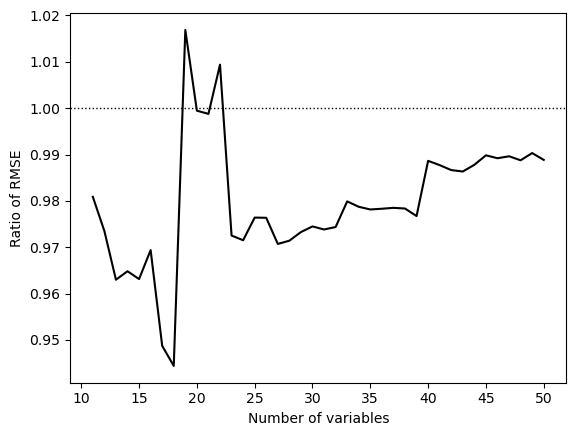

OLS benchmark RMSE : 2.7344
LARS min RMSE : 2.5824
Total specifications selected: 38. 
 Best-RMSE selected variables 18 out of 244
Distribution of frequencies in LARS selection:
count    38.000000
mean      2.674249
std       0.032037
min       2.582414
25%       2.659850
50%       2.674920
75%       2.701012
max       2.732994
Name: rmse, dtype: float64


,series,ticket,description,description 2,freq,first_date,last_date,No Obs,months_lag,nominal,sa,unstructured,type,agg_method,file_name
61,bank_loans_food_and_beverage_services_excludin...,MLOA9803,Commercial Bank Loans (by sector): Food and Be...,NaN,MS,4/1/1986,2/1/2026,479,3,NaN,0.0,0.0,M,mean,boj_bank_loans_bysector.csv
63,bank_loans_government_services_local_government,MLOAB002,Commercial Bank Loans (by sector): Government ...,NaN,MS,4/1/1986,2/1/2026,479,3,NaN,0.0,0.0,M,mean,boj_bank_loans_bysector.csv
64,bank_loans_government_services_other_public_en...,MLOAB004,Commercial Bank Loans (by sector): Government ...,NaN,MS,4/1/1986,2/1/2026,479,3,NaN,0.0,0.0,M,mean,boj_bank_loans_bysector.csv
72,bank_loans_manufacturing_metal_products,MLOA9305,Commercial Bank Loans (by sector): Manufacturi...,NaN,MS,4/1/1986,2/1/2026,479,3,NaN,0.0,0.0,M,mean,boj_bank_loans_bysector.csv
75,bank_loans_manufacturing_sugar_rum_molasses,MLOA9306,Commercial Bank Loans (by sector): Manufacturi...,NaN,MS,4/1/1986,2/1/2026,479,3,NaN,0.0,0.0,M,mean,boj_bank_loans_bysector.csv
89,bank_nonperf_loans_electricity_gas_and_water,MNPL0004,Non-Performing Loans (by customer): Electricit...,NaN,MS,3/1/2017,2/1/2026,108,3,NaN,0.0,0.0,M,mean,boj_bank_nonperf.csv
94,bank_nonperf_loans_mining,MNPL0008,Non-Performing Loans (by customer): Mining,NaN,MS,3/1/2017,2/1/2026,108,3,NaN,0.0,0.0,M,mean,boj_bank_nonperf.csv
95,bank_nonperf_loans_nonbank_financial_institutions,MNPL0009,Non-Performing Loans (by customer): Non-Bank F...,NaN,MS,3/1/2017,2/1/2026,108,3,NaN,0.0,0.0,M,mean,boj_bank_nonperf.csv
99,bank_nonperf_loans_public_sector,MNPL0012,Non-Performing Loans (by customer): Public Sector,NaN,MS,3/1/2017,2/1/2026,108,3,NaN,0.0,0.0,M,mean,boj_bank_nonperf.csv
100,bank_nonperf_loans_tourism,MNPL0013,Non-Performing Loans (by customer): Tourism,NaN,MS,3/1/2017,2/1/2026,108,3,NaN,0.0,0.0,M,mean,boj_bank_nonperf.csv


In [ ]:
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------
# LARS-PRESELECTION
# Steps: 1) Prepare df; 2) Estimate benchmark; 3) LARS Estimation; 4) Best-variables
# ---------------------------------------------
# 1. Preparation: LARS cannot handle Missing Values or Mixed-Data
factors = 1

# Aggregate according to methods described in metadata
try :
    agg_map = metadata.set_index('ticket')['agg_method'].to_dict()
    agg_funcs = {
        col: (agg_map[col] if agg_map[col] in ['mean', 'last', 'sum'] else 'mean')
        for col in data.columns if col in agg_map
    }
    pre_selected = data.resample('QS').agg(agg_funcs)
except :
    pre_selected = data.resample('QS').mean()


pre_selected.index = pd.to_datetime(pre_selected.index)
pre_selected = pre_selected.dropna(how="all", axis=1)
pre_selected = pre_selected.loc[:, pre_selected.isnull().mean() <= 0.75]

# Mean-fill predictors only — leave target_variable as NaN so we can
# identify quarters without observed GDP and drop them from training.
predictors = [c for c in pre_selected.columns if c != target_variable]
pre_selected[predictors] = pre_selected[predictors].fillna(
    pre_selected[predictors].mean(numeric_only=True)
)



# data cannot include periods beyond the GDP we observe
last_gdp = data[target_variable].dropna()
last_gdp = last_gdp.index.max()
pre_selected = pre_selected[pre_selected.index <= last_gdp]
pre_selected.dropna(subset=[target_variable], inplace=True)
del last_gdp

# ---------------------------------------------
# 2. Benchmark RMSE
# ---------------------------------------------
# Split raw data first
X_raw = pre_selected.drop(target_variable, axis=1)
y_all = pre_selected[[target_variable]]

X_train_raw = X_raw[X_raw.index <  pd.to_datetime(test_start_date)]
X_test_raw  = X_raw[X_raw.index >= pd.to_datetime(test_start_date)]
y_train     = y_all[y_all.index <  pd.to_datetime(test_start_date)]
y_test      = y_all[y_all.index >= pd.to_datetime(test_start_date)]

# Drop quarters where GDP was not observed (NaN target = no real observation)
obs_mask    = y_train[target_variable].notna()
y_train     = y_train[obs_mask]
X_train_raw = X_train_raw[obs_mask]

# Fit scaler on train only, transform both
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_raw), index=X_train_raw.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_raw),      index=X_test_raw.index)

# Fit PCA on train only, transform both
pca = PCA(n_components=factors)
X_train = pd.DataFrame(pca.fit_transform(X_train_scaled), index=X_train_raw.index)
X_test  = pd.DataFrame(pca.transform(X_test_scaled),      index=X_test_raw.index)
X_train.columns = [f"PC_{i}" for i in range(factors)]
X_test.columns  = [f"PC_{i}" for i in range(factors)]

benchmark_model = LinearRegression()
benchmark_model.fit(X_train, y_train)
print(f"Training on {len(y_train)} observed GDP quarters")

y_pred = benchmark_model.predict(X_test).ravel()
y_true = y_test.values.ravel()

# Naive baseline: always predict the training-period mean
naive_pred = float(y_train[target_variable].mean())
naive_rmse = float(np.sqrt(np.mean((y_true - naive_pred) ** 2)))

benchmark = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))  # RMSE

print(f"OLS benchmark RMSE : {benchmark:.4f}")

# ---------------------------------------------
# 3. LARS Estimation
# ---------------------------------------------
pre_train = pre_selected[pre_selected.index <  test_start_date]
pre_test  = pre_selected[pre_selected.index >= test_start_date]

# Estimate LARS over a range of variables included in the estimation
# Returns RMSE and variable choice
d = []
for size in range(10,50) :
    selection, rmse = lars_variable_ranking(pre_train, target=target_variable, max_vars=size+1, test = pre_test, factors = factors)
    b = {
        "size" : size+1 ,
        "selected_vars" : selection ,
        "rmse" : rmse
    }
    d.append(b)
d = pd.DataFrame(d)
d.set_index('size', inplace=True)

d['ratio'] = d['rmse']/benchmark

# Minimum RMSE:
# d.loc[d['rmse'].idxmin()]

# ---------------------------------------------
# 4. Best models: define top models and add them to specification list
# ---------------------------------------------

# ---------------------------------------------
# Plot LARS results
# ---------------------------------------------
#threshold = d['ratio'].mean()
# Best threshold is 1: where models outperform non-selected OLS
threshold = 1
d['ratio'].plot(color='black')
plt.axhline(y=threshold, color='black', linestyle=':', linewidth=1)
plt.ylabel("Ratio of RMSE")
plt.xlabel("Number of variables")
plt.legend().set_visible(False)
plt.savefig(f"{PATH_OUTPUT}/{date_str} 3_nwcst Fig lars_ratio.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"OLS benchmark RMSE : {benchmark:.4f}")
print(f"LARS min RMSE : {d['rmse'].min():.4f}")

# ---------------------------------------------

# ---------------------------------------------
# Keep specifications where rmse is below the threshold
# These are the top models
# ---------------------------------------------

spec_list = d[d['ratio']<threshold]
spec_list['selected_vars'] = spec_list['selected_vars'].apply(lambda x: ' '.join(x))
# ---------------------------------------------

# Variables included in best-RMSE LARS:
top_vars = spec_list.loc[spec_list['rmse'].idxmin(), 'selected_vars'].split(" ")
# Variable selection in best-RMSE LARS:
print(f"Total specifications selected: {len(spec_list)}. \n Best-RMSE selected variables {len(top_vars)} out of {len(data.columns)-1}")

# Now define main df using only variables selected
# data = data[[target_variable] + top_vars]

# ---------------------------------------------
# What variables are included in the top selection?
# ---------------------------------------------
del pre_selected

# ---------------------------------------------
# Save estimation parameters for reproducibility
# ---------------------------------------------
parameters = {
    "train_start": train_start_date.strftime("%Y-%m-%d"),
    "test_start": test_start_date.strftime("%Y-%m-%d"),
    "test_end": test_end_date.strftime("%Y-%m-%d"),
    "lars_pca": factors,
    "model_iterations": int(_iter_),
    'lstm n_models' : _iter_lstm ,
    'lstm train_episodes' :_epoch_lstm,
    **run
}

with open(os.path.join(PATH_OUTPUT, "estimation_parameters.json"), "w") as f:
    json.dump(parameters, f, indent=2)

# ---------------------------------------------
# ---------------------------------------------
print("Distribution of frequencies in LARS selection:")
print(spec_list.rmse.describe())

metadata[metadata['ticket'].isin(top_vars)]

Drops half of the specifications at random

In [6]:
# Keep half of the specs
spec_list = spec_list.sample(frac=0.5, random_state=42)

## Specs

Generate specification list

In [7]:
import warnings
warnings.filterwarnings('ignore')
# --- Base / benchmark naming ---
spec_list = spec_list.copy()

spec_list["spec"] = "lars" + spec_list.index.astype(str)
bench_idx = spec_list["rmse"].idxmin()
spec_list.loc[bench_idx, "spec"] = "bench" + str(bench_idx)

# --- Base settings (data_flat=3 only) ---
base = spec_list.assign(gdp_lags=0, PCA=0, data_flat=3)

variants = [base]

# --- Flats branch (data_flat=4 only, no PCA/lag variants) ---
flats = base.assign(data_flat=4)
flats["spec"] = "flats" + flats.index.astype(str)
variants.append(flats)

# --- PCA variants ONLY on base (data_flat=3) ---
p5 = base.assign(PCA=5)
p5["spec"] = p5["spec"] + "p5"
variants.append(p5)

p3 = base.assign(PCA=3)
p3["spec"] = p3["spec"] + "p3"
variants.append(p3)

# --- Lags variant ONLY for p5 specs on base (data_flat=3) ---
p5_l2 = p5.copy()
p5_l2["gdp_lags"] = 2
p5_l2["spec"] = p5_l2["spec"] + "l2"
variants.append(p5_l2)

# --- Final spec_list ---
spec_list = pd.concat(variants, axis=0)

print(f"Total iterations: {len(spec_list)}")
spec_list

Total iterations: 95


,selected_vars,rmse,ratio,spec,gdp_lags,PCA,data_flat
size,,,,,,,
46,MNPL0009 XIMP0002 MXRT0101 MNPL0014 XEMP0002 R...,2.704928,0.989205,lars46,0,0,3
49,MNPL0009 XIMP0002 MXRT0101 MNPL0014 XEMP0002 R...,2.707980,0.990320,lars49,0,0,3
15,MNPL0009 XIMP0002 MXRT0101 MNPL0014 XEMP0002 R...,2.633649,0.963137,lars15,0,0,3
26,MNPL0009 XIMP0002 MXRT0101 MNPL0014 XEMP0002 R...,2.669792,0.976355,lars26,0,0,3
43,MNPL0009 XIMP0002 MXRT0101 MNPL0014 XEMP0002 R...,2.697095,0.986340,lars43,0,0,3
...,...,...,...,...,...,...,...
32,MNPL0009 XIMP0002 MXRT0101 MNPL0014 XEMP0002 R...,2.664359,0.974368,lars32p5l2,2,5,3
21,MNPL0009 XIMP0002 MXRT0101 MNPL0014 XEMP0002 R...,2.731081,0.998769,lars21p5l2,2,5,3
45,MNPL0009 XIMP0002 MXRT0101 MNPL0014 XEMP0002 R...,2.706650,0.989834,lars45p5l2,2,5,3


### Human models

Define any additional model of interest here:

In [8]:
N = [
    {
    'size' : 9 ,
    'selected_vars' : 'UGTR0000 MPAY0001 UBML0000 XEMP0004 XFED0005 XOIL0000 MLOA1000 XMIM0000' ,
    'spec' : 'human1' ,
    'gdp_lags' : 2,
    'PCA' : 3,
    'data_flat' : 3,
    } ,
]
'''
for d in N :
    spec_list = pd.concat(
        [
            spec_list,
            pd.DataFrame( [ d ] ).set_index('size') ] ,
        axis=0
    )
spec_list
'''

"\nfor d in N :\n    spec_list = pd.concat(\n        [\n            spec_list,\n            pd.DataFrame( [ d ] ).set_index('size') ] ,\n        axis=0\n    )\nspec_list\n"

## Spec Trim

Keep only specifications that have shown good past performance.

**Con:** May exclude specifications that were good in some models but bad overall. 

In [9]:
# Read last_performance file into a dataframe
if last_performance is not None :
    last_perf = pd.read_excel(f"{PATH_OUTPUT}/{last_performance}")
    # group last_performance by spec with the min, max, and mean RMSE
    last_perf = last_perf.groupby('spec')['RMSE'].agg(['min', 'max', 'median'])
    # Generate a flag for whether the median RMSE is above or below the overall median
    last_perf['flag'] = last_perf['median']>last_perf['median'].median()
    last_perf = last_perf[['flag']]

    # merge spec_list and last_perf on 'spec' column
    spec_list = spec_list.merge(last_perf, left_on='spec', right_on='spec', how='left')

    # drop selected specifications
    spec_list = spec_list[spec_list['flag'] != True]
    spec_list

## Nowcasting

WORKSHOP EDIT:

Reduce specifications due to time constraint

In [10]:
spec_list = spec_list[:2]

In [11]:
# =========================================================
# FULL JUPYTER-SAFE PARALLEL VERSION (Windows + Jupyter Lab)
# Parallelize across spec_list rows using joblib (loky)
# Save results EVERY 25 specs and at the end
# WITH A REAL PROGRESS BAR (completed specs + ETA)
# =========================================================

import traceback, timeit, os, warnings
warnings.filterwarnings("ignore")
import pandas as pd

from joblib import Parallel, delayed
from tqdm.auto import tqdm

# --- progress bar integration for joblib ---
# If you don't have it yet: pip install tqdm-joblib
from tqdm_joblib import tqdm_joblib


# ---------------------------------------------------------
# 0) Thread caps (IMPORTANT) — set BEFORE heavy numeric work
# ---------------------------------------------------------
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
torch.set_num_threads(2)  # lets each worker use 2 CPU threads for PyTorch ops

# 8 cores -> typically best is 7 workers (leave 1 core free)
# If run['lstm']==1 frequently, set this to 4–6 instead.
MAX_WORKERS = 6 if run.get('lstm', 0) == 1 else max(1, os.cpu_count() - 1)

print(f"Detected {os.cpu_count()} logical cores. Using {MAX_WORKERS} workers")

# ---------------------------------------------------------
# 1) Load existing output tables once
# ---------------------------------------------------------
start = timeit.default_timer()

try:
    stop
    result_table = pd.read_excel(f"{PATH_OUTPUT}/{forecast_file}", index_col="date")
    performance_table = pd.read_excel(f"{PATH_OUTPUT}/{performance_file}")
    outofsample_table = pd.read_excel(f"{PATH_OUTPUT}/{outofsample_file}", index_col="date")
    print("Existing files loaded.")
except Exception:
    print("No former files exist. Starting from spec 1.")
    performance_table = pd.DataFrame()
    result_table = pd.DataFrame()
    outofsample_table = pd.DataFrame()

print(f"Running and saving in: {performance_file}")


# ---------------------------------------------------------
# 2) Build list of specs to run (skip already-done)
# ---------------------------------------------------------
done_specs = set(performance_table["spec"].unique()) if "spec" in performance_table.columns else set()

rows = []
for _, row in spec_list.iterrows():
    spec = row["spec"]
    if spec in done_specs:
        continue
    rows.append(row.to_dict())

print(f"Total specs queued: {len(rows)} (skipping {len(done_specs)} already done)")


# ---------------------------------------------------------
# 3) Worker: runs ONE spec and returns its outputs
# ---------------------------------------------------------
def _run_one_spec_worker(row_dict,
                         data, metadata,
                         target_variable, lags, run,
                         train_start_date, test_start_date, test_end_date,
                         _iter_, desired_date):
    """
    Returns:
      (spec, perf_df, fcst_df, oos_df, err_str)
    where err_str is None if success, else traceback string.
    """
    try:
        spec = row_dict["spec"]
        XVars = row_dict["selected_vars"].split(" ")

        # params
        gdp_lags = row_dict.get("gdp_lag", 0)
        param_pca = row_dict.get("PCA", 3)
        data_flat = row_dict.get("data_flat", 3)

        dt_n = row_dict.get("dt_n", _iter_)
        rf_n = row_dict.get("rf_n", dt_n)
        gbt_n = row_dict.get("gbt_n", dt_n)

        # local imports inside worker (safe in spawned processes)
        from sklearn.preprocessing import StandardScaler
        from sklearn.decomposition import PCA

        scaler = StandardScaler()

        # slice data for this spec
        df = data[[c for c in data.columns if c in XVars or c == target_variable]].copy()

        # GENERATE TRAIN/TEST DATASET
        df = df.reset_index(drop=False)
        df.dropna(axis=1, thresh=23, inplace=True)

        test = df.loc[(df.date >= train_start_date) & (df.date <= test_end_date), :].reset_index(drop=True)

        # DATES AND ACTUAL VALUES
        dates = pd.date_range(test_start_date, test_end_date, freq="3MS").strftime("%Y-%m-%d").tolist()
        actuals = list(test.loc[test.date.astype(str).isin(dates), target_variable].values)

        pred_ols  = {k: [] for k in lags}
        pred_olsr = {k: [] for k in lags}
        pred_enet = {k: [] for k in lags}
        pred_lasso= {k: [] for k in lags}
        pred_dt   = {k: [] for k in lags}
        pred_rf   = {k: [] for k in lags}
        pred_gbt  = {k: [] for k in lags}
        pred_lstm = {k: [] for k in lags}

        for date in dates:

            # define rolling-window training set
            train = test.loc[
                test.date <= str(pd.to_datetime(date) - pd.tseries.offsets.DateOffset(months=3))[:10],
                :
            ]
            transformed_train = mean_fill_dataset(train, train)

            # -----------------------------------------------------------------
            # PCA scaling (if enabled)
            if param_pca not in (False, 0, None):
                ncomp = 1 if param_pca is True else int(param_pca)

                X = transformed_train.set_index("date").drop(target_variable, axis=1)
                X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns).dropna(axis=1)

                Z = PCA(n_components=ncomp).fit_transform(X)
                Z = pd.DataFrame(Z).rename(columns=lambda x: f"PC_{x}")

                transformed_train = pd.concat([transformed_train[["date", target_variable]], Z], axis=1)

            ttrain = flatten_data(transformed_train, target_variable, data_flat)

            # keep quarterly observations and drop early observations
            ttrain = (
                ttrain.loc[ttrain.date.dt.month.astype(int).isin([3, 6, 9, 12]), :]
                     .fillna(ttrain.mean(numeric_only=True))
                     .dropna(axis=1)
                     .reset_index(drop=True)
            )
            ttrain = lagged_target(ttrain, gdp_lags)

            xt = ttrain.drop(["date", target_variable], axis=1)
            yt = ttrain[target_variable]

            # -----------------------------------------------------------------
            # Apply model in train
            if run.get("ols", 0) == 1:
                ols_fit, ols_vars = fit_ols(yt, xt)

            if run.get("olsr", 0) == 1:
                olsr_fit, olsr_vars = fit_olsr(yt, xt)

            if run.get("enet", 0) == 1:
                enet_fit, enet_vars = fit_enet(yt, xt)

            if run.get("lasso", 0) == 1:
                lasso_fit, lasso_vars = fit_lasso(yt, xt)

            if run.get("dt", 0) == 1:
                dt_fit, dt_vars = fit_dt(yt, xt, ModelN=dt_n)

            if run.get("rf", 0) == 1:
                rf_fit, rf_vars = fit_rf(yt, xt, ModelN=rf_n)

            if run.get("gbt", 0) == 1:
                gbt_fit, gbt_vars = fit_gbt(yt, xt, ModelN=gbt_n)

            if run.get("lstm", 0) == 1:
                # If you use torch heavily and see instability, consider:
                # import torch; torch.set_num_threads(1); torch.set_num_interop_threads(1)
                lstm_fit, lstm_vars = fit_lstm(transformed_train, gdp_lags=gdp_lags)

            # -----------------------------------------------------------------
            # Publication Lags in Test data
            for lag in lags:
                tmp_data = gen_lagged_data(metadata, test, date, lag)
                tmp_data = mean_fill_dataset(train, tmp_data)

                if param_pca not in (False, 0, None):
                    ncomp = 1 if param_pca is True else int(param_pca)

                    X = tmp_data.set_index("date").drop(target_variable, axis=1)
                    X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns).dropna(axis=1)

                    Z = PCA(n_components=ncomp).fit_transform(X)
                    Z = pd.DataFrame(Z).rename(columns=lambda x: f"PC_{x}")

                    tmp_data = pd.concat([tmp_data[["date", target_variable]], Z], axis=1)

                test_data = flatten_data(tmp_data, target_variable, data_flat)
                test_data = lagged_target(test_data, gdp_lags)
                test_data = test_data.loc[test_data["date"] == date, :].drop(["date", target_variable], axis=1)

                # Predicted values
                if run.get("ols", 0) == 1:
                    pred_ols = predict_ols(ols_fit, test_data, ols_vars, date, pred_ols, lag)

                if run.get("olsr", 0) == 1:
                    pred_olsr = predict_olsr(olsr_fit, test_data, olsr_vars, date, pred_olsr, lag)

                if run.get("enet", 0) == 1:
                    pred_enet = predict_enet(enet_fit, test_data, enet_vars, date, pred_enet, lag)

                if run.get("lasso", 0) == 1:
                    pred_lasso = predict_lasso(lasso_fit, test_data, lasso_vars, date, pred_lasso, lag)

                if run.get("dt", 0) == 1:
                    pred_dt = predict_dt(dt_fit, test_data, dt_vars, date, pred_dt, lag)

                if run.get("rf", 0) == 1:
                    pred_rf = predict_rf(rf_fit, test_data, rf_vars, date, pred_rf, lag)

                if run.get("gbt", 0) == 1:
                    pred_gbt = predict_gbt(gbt_fit, test_data, gbt_vars, date, pred_gbt, lag)

                if run.get("lstm", 0) == 1:
                    pred_lstm = predict_lstm(lstm_fit, tmp_data, lstm_vars, date, pred_lstm, lag, gdp_lags=gdp_lags)

        # -----------------------------------------------------------------
        # Prepare Tables (ONLY this spec)
        perf_parts = []
        fcst_parts = []

        if run.get("ols", 0) == 1:
            perf_parts.append(perform_tab(pred_ols, "OLS", spec, actuals))
            fcst_parts.append(forecast_table(pred_ols, "OLS", spec, actuals, dates))

        if run.get("olsr", 0) == 1:
            perf_parts.append(perform_tab(pred_olsr, "OLSR", spec, actuals))
            fcst_parts.append(forecast_table(pred_olsr, "OLSR", spec, actuals, dates))

        if run.get("enet", 0) == 1:
            perf_parts.append(perform_tab(pred_enet, "ENET", spec, actuals))
            fcst_parts.append(forecast_table(pred_enet, "ENET", spec, actuals, dates))

        if run.get("lasso", 0) == 1:
            perf_parts.append(perform_tab(pred_lasso, "LASSO", spec, actuals))
            fcst_parts.append(forecast_table(pred_lasso, "LASSO", spec, actuals, dates))

        if run.get("dt", 0) == 1:
            perf_parts.append(perform_tab(pred_dt, "DT", spec, actuals))
            fcst_parts.append(forecast_table(pred_dt, "DT", spec, actuals, dates))

        if run.get("rf", 0) == 1:
            perf_parts.append(perform_tab(pred_rf, "RF", spec, actuals))
            fcst_parts.append(forecast_table(pred_rf, "RF", spec, actuals, dates))

        if run.get("gbt", 0) == 1:
            perf_parts.append(perform_tab(pred_gbt, "GBT", spec, actuals))
            fcst_parts.append(forecast_table(pred_gbt, "GBT", spec, actuals, dates))

        if run.get("lstm", 0) == 1:
            perf_parts.append(perform_tab(pred_lstm, "LSTM", spec, actuals))
            fcst_parts.append(forecast_table(pred_lstm, "LSTM", spec, actuals, dates))

        perf_df = pd.concat(perf_parts, axis=0) if perf_parts else pd.DataFrame()
        fcst_df = pd.concat(fcst_parts, axis=0) if fcst_parts else pd.DataFrame()

        # OOS block removed here for stability/speed in parallel
        oos_parts = []
        # -----------------------------------------------------------------
        # OUT OF SAMPLE ESTIMATION
        # -----------------------------------------------------------------
        if desired_date is not None:
            # Extend dataframe to desired_date
            while desired_date > df['date'].max(): 
                df.loc[len(df), "date"] = df['date'].max() + pd.DateOffset(months=1)
            
            transformed_new_data = mean_fill_dataset(df, df)
            
            # Apply PCA if specified
            if param_pca not in (False, 0, None):
                X = pd.DataFrame(scaler.fit_transform(transformed_new_data.set_index('date').drop(target_variable, axis=1)))
                X.columns = transformed_new_data.set_index('date').drop(target_variable, axis=1).columns
                X = X.dropna(axis=1)
                pca = PCA(n_components=param_pca)
                
                X = pca.fit_transform(X)
                X = pd.DataFrame(X)
                X.rename(columns=lambda x: f'PC_{x}', inplace=True)
                
                transformed_new_data = pd.concat([transformed_new_data[['date', target_variable]], X], axis=1)
            
            # Prepare OOS data
            transformed_data = flatten_data(transformed_new_data, target_variable, data_flat)
            transformed_data = lagged_target(transformed_data, gdp_lags)
            transformed_data = transformed_data[transformed_data['date'] > date]
            transformed_data = transformed_data[transformed_data['date'] <= desired_date]
            transformed_data = transformed_data.loc[transformed_data.date.dt.month.astype(int).isin([3,6,9,12]),:].fillna(transformed_train.mean()).dropna(axis=1)
            new_dates = transformed_data['date']
            transformed_data = transformed_data.drop(["date", target_variable], axis=1).reset_index(drop=True)
            
            # Initialize empty outofsample_table (assuming it's a list or DataFrame)
            outofsample_table = pd.DataFrame()
            
            # Run OOS forecasts
            if run.get('ols', 0) == 1:
                outofsample_table = oos_ols(ols_fit, transformed_data, train_vars=ols_vars, 
                                           table=outofsample_table, new_dates=new_dates, spec=spec, desired_date=desired_date)
            if run.get('olsr', 0) == 1:
                outofsample_table = oos_olsr(olsr_fit, transformed_data, train_vars=olsr_vars,
                                            table=outofsample_table, new_dates=new_dates, spec=spec, desired_date=desired_date)
            if run.get('enet', 0) == 1:
                outofsample_table = oos_enet(enet_fit, transformed_data, train_vars=enet_vars,
                                            table=outofsample_table, new_dates=new_dates, spec=spec, desired_date=desired_date)
            if run.get('lasso', 0) == 1:
                outofsample_table = oos_lasso(lasso_fit, transformed_data, train_vars=lasso_vars,
                                             table=outofsample_table, new_dates=new_dates, spec=spec, desired_date=desired_date )
            if run.get('dt', 0) == 1:
                outofsample_table = oos_dt(dt_fit, transformed_data, train_vars=dt_vars,
                                          table=outofsample_table, new_dates=new_dates, spec=spec, desired_date=desired_date )
            if run.get('rf', 0) == 1:
                outofsample_table = oos_rf(rf_fit, transformed_data, train_vars=rf_vars,
                                          table=outofsample_table, new_dates=new_dates, spec=spec, desired_date=desired_date )
            if run.get('gbt', 0) == 1:
                outofsample_table = oos_gbt(gbt_fit, transformed_data, train_vars=gbt_vars,
                                           table=outofsample_table, new_dates=new_dates , spec=spec, desired_date=desired_date)
            if run.get('lstm', 0) == 1:
                outofsample_table = oos_lstm(lstm_fit, transformed_new_data, train_vars=lstm_vars,
                                            table=outofsample_table, new_dates=new_dates, spec=spec, desired_date=desired_date)
            
            # Convert to DataFrame if needed
            oos_df = pd.DataFrame(outofsample_table) if isinstance(outofsample_table, list) else outofsample_table

        return spec, perf_df, fcst_df, oos_df, None

    except Exception:
        return row_dict.get("spec", "UNKNOWN"), None, None, None, traceback.format_exc()



# ---------------------------------------------------------
# 4) Run in parallel (joblib loky) and collect results
# ---------------------------------------------------------
perf_out, fcst_out, oos_out = [], [], []
failed = []

# NEW: Set batch size for incremental saves
SAVE_BATCH_SIZE = 25
specs_processed = 0

if len(rows) > 0:
    '''
    results = Parallel(n_jobs=MAX_WORKERS, backend="loky", verbose=10)(
        delayed(_run_one_spec_worker)(
            row_dict,
            data, metadata,
            target_variable, lags, run,
            train_start_date, test_start_date, test_end_date,
            _iter_, desired_date
        )
        for row_dict in tqdm(rows, desc="Queueing specs")
    )
    '''
    results = []
    with tqdm(total=len(rows), desc="Processing specs") as pbar:
        for result in Parallel(n_jobs=MAX_WORKERS, backend="loky", verbose=5, return_as="generator")(
            delayed(_run_one_spec_worker)(
                row_dict, data, metadata, target_variable, lags, run,
                train_start_date, test_start_date, test_end_date, _iter_, desired_date
            ) for row_dict in rows
        ):
            results.append(result)
            pbar.update(1)

    for spec, perf_df, fcst_df, oos_df, err in results:
        if err is not None:
            failed.append(spec)
            print(f"FAILED spec={spec}\n{err}\n")
            continue

        if perf_df is not None and not perf_df.empty:
            perf_out.append(perf_df)
        if fcst_df is not None and not fcst_df.empty:
            fcst_out.append(fcst_df)
        if oos_df is not None and not oos_df.empty:
            oos_out.append(oos_df)
        
        specs_processed += 1
        
        # NEW: Save every SAVE_BATCH_SIZE specs
        if specs_processed % SAVE_BATCH_SIZE == 0:
            print(f"\n{'='*60}")
            print(f"SAVING BACKUP after {specs_processed} specs")
            print(f"{'='*60}")
            # Merge with existing tables
            if perf_out:
                temp_perf = pd.concat([performance_table] + perf_out, axis=0)
                temp_perf.to_excel(f"{PATH_OUTPUT}/{performance_file}")
                print(f"Saved {len(temp_perf)} rows to {performance_file}")
            
            if fcst_out:
                temp_fcst = pd.concat([result_table] + fcst_out, axis=0)
                temp_fcst.index = pd.to_datetime(temp_fcst.index).strftime("%Y-%m-%d")
                temp_fcst.to_excel(f"{PATH_OUTPUT}/{forecast_file}", index_label="date")
                print(f"Saved {len(temp_fcst)} rows to {forecast_file}")
            
            if oos_out:
                temp_oos = pd.concat([outofsample_table] + oos_out, axis=0)
                temp_oos.index = pd.to_datetime(temp_oos.index).strftime("%Y-%m-%d")
                temp_oos.to_excel(f"{PATH_OUTPUT}/{outofsample_file}", index_label="date")
                print(f"Saved {len(temp_oos)} rows to {outofsample_file}")
            
            print(f"{'='*60}\n")
        pbar.update(1)

# ---------------------------------------------------------
# 5) Final merge and save (FAST)
# ---------------------------------------------------------
if perf_out:
    performance_table = pd.concat([performance_table] + perf_out, axis=0, ignore_index=False)

if fcst_out:
    result_table = pd.concat([result_table] + fcst_out, axis=0)

if oos_out:
    outofsample_table = pd.concat([outofsample_table] + oos_out, axis=0)

# Final save
performance_table.to_excel(f"{PATH_OUTPUT}/{performance_file}")

result_table.index = pd.to_datetime(result_table.index).strftime("%Y-%m-%d")
result_table.index = pd.to_datetime(result_table.index)
result_table.to_excel(f"{PATH_OUTPUT}/{forecast_file}", index_label="date")

outofsample_table.index = pd.to_datetime(outofsample_table.index).strftime("%Y-%m-%d")
outofsample_table.index = pd.to_datetime(outofsample_table.index)
outofsample_table.to_excel(f"{PATH_OUTPUT}/{outofsample_file}", index_label="date")

run_time = timeit.default_timer() - start
print(f"\nTotal runtime: {run_time:.2f} seconds")
print(f"Saved in {performance_file}")
if failed:
    print(f"Failed specs ({len(failed)}): {failed}")

print(performance_table['RMSE'].describe())
print(f"Original Benchmark: {benchmark}")
performance_table

Detected 16 logical cores. Using 6 workers
No former files exist. Starting from spec 1.
Running and saving in: 20260505 3_nwcst Tab perf.xlsx
Total specs queued: 2 (skipping 0 already done)


Processing specs: 100%|██████████| 2/2 [02:20<00:00, 70.18s/it] 



Total runtime: 140.85 seconds
Saved in 20260505 3_nwcst Tab perf.xlsx
count    80.000000
mean      4.981033
std       6.036302
min       2.291649
25%       2.507918
50%       2.558233
75%       3.149853
max      30.802763
Name: RMSE, dtype: float64
Original Benchmark: 2.734448003356505


,RMSE,estimator,spec
Vintage,,,
-2,2.298953,OLS,lars46
-1,2.291649,OLS,lars46
0,2.624861,OLS,lars46
1,12.721925,OLS,lars46
2,13.272481,OLS,lars46
...,...,...,...
-2,2.366554,LSTM,lars49
-1,2.446009,LSTM,lars49
0,2.402428,LSTM,lars49


In [ ]:
result_table

In [ ]:
outofsample_table